In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import seaborn as sns
from typing import Optional

def plot_age_prediction(adata):
    from sklearn.metrics import r2_score
    from scipy.stats import spearmanr
    import seaborn as sns
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 6))

    datasets = adata.obs['dataset'].unique()
    for dataset in datasets:
        subset = adata.obs[adata.obs['dataset'] == dataset]
        age = subset['age']
        pred = subset['predicted_age']

        r2 = r2_score(age, pred)
        rho, _ = spearmanr(age, pred)

        label = f"{dataset} (ρ={rho:.2f}, R²={r2:.2f})"
        sns.scatterplot(x=age, y=pred, s=10, ax=ax, label=label)

    # Plot diagonal reference line
    min_age = adata.obs['age'].min()
    max_age = adata.obs['age'].max()
    ax.plot([min_age, max_age], [min_age, max_age], 'r--', label="Identity")

    ax.set_xlabel("True Age")
    ax.set_ylabel("Predicted Age")
    ax.legend()
    ax.set_title("Age Prediction per Dataset")
    plt.tight_layout()
    plt.show()

# Prepare data

In [2]:
import numpy as np
from scipy import sparse
from anndata import AnnData

def align_feature_space(adata, gene_names):
    # - load the model
    if False:
        model, gene_names = retrieve_function(reg_type, cell_type, data_type, feature_type, version)
    else:
        gene_names = adata_train.var_names.tolist()

    var_names = np.array(adata.var_names)
    var_index = {gene: i for i, gene in enumerate(var_names)}

    # Collect indices or mark as -1 for missing
    idxs = np.array([var_index.get(gene, -1) for gene in gene_names])

    # Create a matrix with correct shape
    rows = adata.shape[0]
    cols = len(gene_names)
    X_aligned = sparse.lil_matrix((rows, cols))

    # Fill in available gene columns
    present = idxs != -1
    if present.sum() > 0:
        X_aligned[:, present] = adata.X[:, idxs[present]]

    # Convert to CSR for efficiency
    X_aligned = X_aligned.tocsr()

    # Create new AnnData object
    new_adata = AnnData(
        X=X_aligned,
        obs=adata.obs.copy(),
        var={"gene_symbols": gene_names},
    )
    new_adata.var_names = gene_names

    return new_adata


In [3]:
import anndata as ad
from ciim.src.common import save_dir
import pandas as pd
data_type = 'bulk'
feature_type = 'gene_expression'
cell_type = 'CD8T'
age_limit = 20

def merge_prepare_data(datasets):
    adata_store = []
    for dataset in datasets:
        # adata = prepare_input(dataset, cell_type, feature_type=feature_type, data_type=data_type)
        adata = ad.read_h5ad(f"{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
        adata = adata[(adata.obs['age']>age_limit)].copy()
        # print(adata.obs['age'].min())
        if 'SLE' in dataset:
            adata = adata[adata.obs['disease']=='normal'].copy()
        adata_store.append(adata)
    adata_all = ad.concat(adata_store, join='inner', axis=0)

    return adata_all
adata_train = merge_prepare_data(datasets=['data1', 'data7_allTPs_jalil'])
adata_test = merge_prepare_data(datasets=['SLE_European'])
adata_test = align_feature_space(adata_test, gene_names=adata_train.var_names.tolist())

# Create models

In [4]:
import torch
from scvi.dataloaders import AnnDataLoader

In [9]:
import torch
from anndata import AnnData
from scvi.model.base import BaseModelClass, UnsupervisedTrainingMixin, VAEMixin, EmbeddingMixin
from scvi.module.base import BaseModuleClass, LossOutput, EmbeddingModuleMixin
from scvi.module import VAE
from scvi import REGISTRY_KEYS
from scvi.data import AnnDataManager
from torch.distributions import Normal, kl_divergence
from scvi.nn import Embedding
from scvi.data.fields import (
    LayerField,
    CategoricalObsField,
    NumericalObsField,
    CategoricalJointObsField,
    NumericalJointObsField,
)
import torch.nn as nn
import torch.nn.functional as F
from scvi.train import TrainingPlan, TrainRunner
from scvi.dataloaders import DataSplitter
from scvi.train import TrainRunner

class Encoder(nn.Module):
    def __init__(self, n_genes, n_latent, hidden_dim=128, dropout=0.2, batch_emb_dim=2, latent_type='vanilla'):
        super().__init__()
        self.fc1 = nn.Linear(n_genes + batch_emb_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, n_latent)
        self.fc_logvar = nn.Linear(hidden_dim, n_latent)
        self.dropout = nn.Dropout(dropout)
        self.latent_type = latent_type

    def forward(self, x, batch_emb):
        x = torch.cat([x, batch_emb], dim=1)
        h = F.relu(self.fc1(x))
        h = self.dropout(h)
        mu = self.fc_mu(h)

        if self.latent_type == 'vanilla':
            z = mu
            logvar = torch.zeros_like(mu)
        elif self.latent_type == 'generative':
            logvar = self.fc_logvar(h)
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            z = mu + eps * std
        else:
            raise ValueError(f'{self.latent_type} is not defined.')

        return z, mu, logvar


class Decoder(nn.Module):
    def __init__(self, n_latent, n_genes, batch_emb_dim, hidden_dim=128):
        super().__init__()
        self.fc1 = nn.Linear(n_latent + batch_emb_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, n_genes)

    def forward(self, z, batch_emb):
        z = torch.cat([z, batch_emb], dim=1)
        h = F.relu(self.fc1(z))
        return self.fc2(h)

class AgeRegressor(nn.Module):
    def __init__(self, n_latent, hidden_dim, batch_emb_dim):
        super().__init__()
        self.fc1 = nn.Linear(n_latent + batch_emb_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)

    def forward(self, z, batch_emb):
        z = torch.cat([z, batch_emb], dim=1)
        h = F.relu(self.fc2(F.relu(self.fc1(z))))
        return self.fc3(h)

class myModule(BaseModuleClass):
    def __init__(
        self,
        n_genes: int,
        n_batches: int,
        n_latent: int = 10,
        hidden_dim: int = 128,
        dropout: float = 0.2,
        batch_emb_dim: int = 2,
        age_loss_weight: float = 1.0,
        latent_type: str = "vanilla",
    ):
        super().__init__()
        self.batch_embed = Embedding(n_batches, batch_emb_dim)
        self.encoder = Encoder(n_genes, n_latent, hidden_dim, dropout, batch_emb_dim, latent_type)
        self.decoder = Decoder(n_latent, n_genes, batch_emb_dim, hidden_dim)
        self.age_head = AgeRegressor(n_latent, hidden_dim, batch_emb_dim)
        self.age_loss_weight = age_loss_weight
        self.latent_type = latent_type

    def _get_inference_input(self, tensors):
        return {
            "x": tensors[REGISTRY_KEYS.X_KEY],
            "batch_idx": tensors.get(REGISTRY_KEYS.BATCH_KEY, None),
        }

    def _get_generative_input(self, tensors: dict, inference_outputs: dict):
        return {
            "z": inference_outputs["z"],
            "batch_emb": inference_outputs["batch_emb"]
        }

    def inference(self, x, batch_idx=None):
        x = x.to(self.device)
        batch_emb = self.batch_embed(batch_idx.to(self.device).long()) if batch_idx is not None else torch.zeros(x.shape[0], self.batch_embed.embedding_dim, device=self.device)
        batch_emb = batch_emb.reshape(x.shape[0], -1)  # Ensure batch_emb is of shape (batch_size, batch_emb_dim)
        z, mu, logvar = self.encoder(x, batch_emb)
        return {"z": z, "qzm": mu, "qzv": torch.exp(logvar), "batch_emb": batch_emb}

    def generative(self, z, batch_emb):
        recon_x = self.decoder(z, batch_emb)
        age_pred = self.age_head(z, batch_emb).squeeze()
        return {"recon_x": recon_x, "age_pred": age_pred}

    def loss(self, tensors, inference_outputs, generative_outputs) -> LossOutput:
        x = tensors[REGISTRY_KEYS.X_KEY]
        age_true = tensors[REGISTRY_KEYS.LABELS_KEY].float()
        recon_x = generative_outputs["recon_x"]
        age_pred = generative_outputs["age_pred"]
        qz_m = inference_outputs["qzm"]
        qz_v = inference_outputs["qzv"]

        recon_loss = F.mse_loss(recon_x, x, reduction="none").sum(dim=1)

        if self.latent_type == "vanilla":
            kl_div = torch.zeros_like(recon_loss)
        else:
            std = torch.sqrt(qz_v)
            post = Normal(qz_m, std)
            prior = Normal(torch.zeros_like(qz_m), torch.ones_like(std))
            kl_div = kl_divergence(post, prior).sum(dim=1)

        age_loss = F.mse_loss(age_pred, age_true.squeeze(), reduction="none")
        loss = (recon_loss + kl_div + self.age_loss_weight * age_loss).mean()

        return LossOutput(
            loss=loss,
            reconstruction_loss=recon_loss,
            kl_local=kl_div,
            kl_global=0.0,
            extra_metrics={"age_loss": age_loss.mean()}
        )

class myModel(UnsupervisedTrainingMixin, BaseModelClass, VAEMixin):
    def __init__(self, adata: AnnData, **model_kwargs):
        super().__init__(adata)
        self.module = myModule(
            n_genes=self.summary_stats["n_vars"],
            n_batches=self.summary_stats["n_batch"],
            **model_kwargs,
        )
        self._model_summary_string = f"CustomVAEAge Model"
        self.init_params_ = self._get_init_params(locals())

    @classmethod
    def setup_anndata_test(cls, adata: AnnData):
        batch_name = adata.obs[cls.batch_key].unique()
        assert len(batch_name) == 1, f"Multiple batches found: {batch_name}"
        batch_name = batch_name[0]

        adata.obs[cls.batch_key] = adata.obs[cls.batch_key].astype('category')
        adata.obs[cls.batch_key] = adata.obs[cls.batch_key].cat.set_categories(
            cls._train_batches + [batch_name]
        )
        cls.setup_anndata(adata, is_train=False, batch_key=cls.batch_key)
        

    @classmethod
    def setup_anndata(cls, adata: AnnData, is_train=True, batch_key=None, layer=None, labels_key="age", **kwargs):
        if is_train:
            cls._train_batches = adata.obs[batch_key].unique().tolist()
            cls.batch_key = batch_key
            cls.labels_key = labels_key
        cls._all_batches = adata.obs[batch_key].cat.categories.tolist()
        setup_method_args = cls._get_setup_method_args(**locals())
        anndata_fields = [
            LayerField(REGISTRY_KEYS.X_KEY, layer, is_count_data=False),
            CategoricalObsField(REGISTRY_KEYS.BATCH_KEY, batch_key),
            NumericalObsField(REGISTRY_KEYS.LABELS_KEY, labels_key),
        ]
        adata_manager = AnnDataManager(fields=anndata_fields, setup_method_args=setup_method_args)
        adata_manager.register_fields(adata, **kwargs)
        cls.register_manager(adata_manager)
        

    def extend_batch_embedding(self, adata: AnnData):
        batch_name = adata.obs[self.batch_key].unique()[0]

        if batch_name in self._all_batches:
            raise ValueError(f"Batch '{batch_name}' already exists in the model.")

        old_n_batches = self.module.batch_embed.num_embeddings
        print('old_n_batches: ', old_n_batches)
        
        added = 1
        self.module.batch_embed = Embedding.extend(self.module.batch_embed, init=added, freeze_prev=True)

    def predict_age(self, adata):
        if not self.is_trained_:
            raise RuntimeError("Please train the model first.")
        adata = self._validate_anndata(adata)
        self.module.eval()

        batch = torch.tensor(adata.obs["dataset"].cat.codes.values, device=self.module.device)
        X = adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X
        X = torch.from_numpy(X).to(self.module.device).float() if not torch.is_tensor(X) else X.float().to(self.module.device)

        with torch.no_grad():
            rr = self.module.inference(X, batch)
            latent = rr["z"]
            batch_emb = rr['batch_emb']
            age_pred = self.module.age_head(latent, batch_emb).cpu().numpy().squeeze()

        adata.obs["predicted_age"] = age_pred
        return adata
    

    def train_test(
        self,
        adata_test,
        max_epochs: int = 100,
        train_size: float = 0.9,
        validation_size: float = 0.1,
        batch_size: int = 128,
        lr: float = 0.05,
        device: str = "cuda" if torch.cuda.is_available() else "cpu",
    ):
        # Prepare the new anndata for use
        # self._register_manager_for_instance(
        #     self.adata_manager.transfer_fields(adata_test, extend_categories=True)
        # )
        # self._validate_anndata(adata_test)
        # adata_test = adata_test.copy()  # prevent modifying original object

        # self.module.to(device)
        # self.module.train()

        # # Freeze all parameters
        # for param in self.module.parameters():
        #     param.requires_grad = False

        # # Unfreeze only batch embedding weights
        # embed_layer = self.module.batch_embed
        # embed_layer.weight.requires_grad = True
        # new_index = embed_layer.num_embeddings - 1

        # optimizer = torch.optim.Adam([embed_layer.weight], lr=lr)

        data_splitter = DataSplitter(
            self.adata,
            train_size=train_size,
            validation_size=validation_size,
            batch_size=batch_size,
        )
        # defines optimizers, training step, val step, logged metrics
        training_plan = TrainingPlan(
            self.module,
            len(data_splitter.train_idx),
        )
        # creates Trainer, pre and post training procedures (Trainer.fit())
        runner = TrainRunner(
            self,
            training_plan=training_plan,
            data_splitter=data_splitter,
            max_epochs=max_epochs,
            **kwargs,
        )
        return runner()

adata = adata_train
myModel.setup_anndata(adata, batch_key="dataset", labels_key="age")
model = myModel(adata, n_latent=100, batch_emb_dim=10)
model.train(max_epochs=2)

model.extend_batch_embedding(adata_test)
myModel.setup_anndata_test(adata_test)

model.train_test(adata_test, max_epochs=2)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 2/2: 100%|██████████| 2/2 [00:00<00:00,  3.08it/s, v_num=1, train_loss_step=3.53e+3, train_loss_epoch=7.95e+3]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 2/2: 100%|██████████| 2/2 [00:00<00:00,  3.04it/s, v_num=1, train_loss_step=3.53e+3, train_loss_epoch=7.95e+3]
old_n_batches:  2


AttributeError: 'AnnData' object has no attribute 'adata'

In [52]:
# Create dataloader

dl = model._make_data_loader(adata_test, shuffle=True)

In [58]:

def move_batch_to_device(batch, device):
    return {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

max_epochs = 100
for epoch in range(max_epochs):
    total_loss = 0
    for batch in dl:
        batch = move_batch_to_device(batch, device=model.module.device)  # fixed line
        print(batch.keys())
        outputs = model.module(**batch)
        loss = outputs["loss"]
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

dict_keys(['X', 'batch', 'labels'])


TypeError: BaseModuleClass.forward() got an unexpected keyword argument 'X'

In [61]:
# help(model.module.forward)

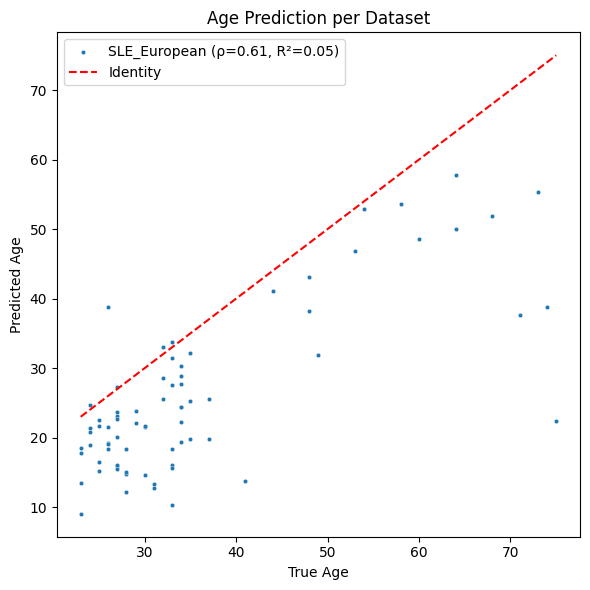

In [23]:
adata_test = model.predict_age(adata_test)
plot_age_prediction(adata_test)

In [8]:
# # - freeze the model parameters
# for param in model.module.parameters():
#     param.requires_grad = False

In [9]:
# # Unfreeze the new embeddings
# embed_layer = model.module.batch_embed
# n_old = embed_layer.num_embeddings - embed_layer.additional_embeddings.shape[0]
# embed_layer.additional_embeddings.requires_grad_(True)

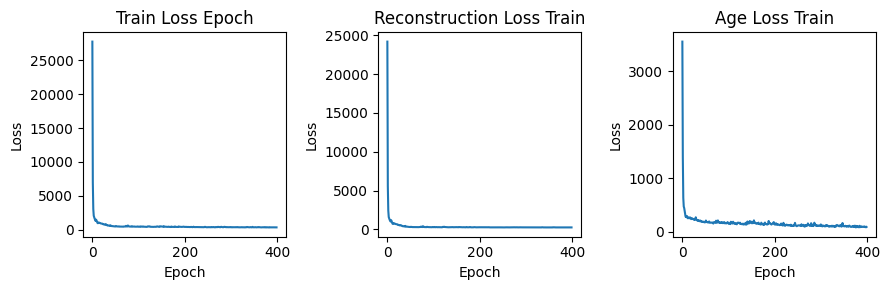

In [10]:
history = model.history
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i, key in enumerate(['train_loss_epoch', 'reconstruction_loss_train', 'age_loss_train']):
    sns.lineplot(data=history[key], ax=axes[i])
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].set_title(key.replace('_', ' ').title())
    axes[i].get_legend().remove()
plt.tight_layout()

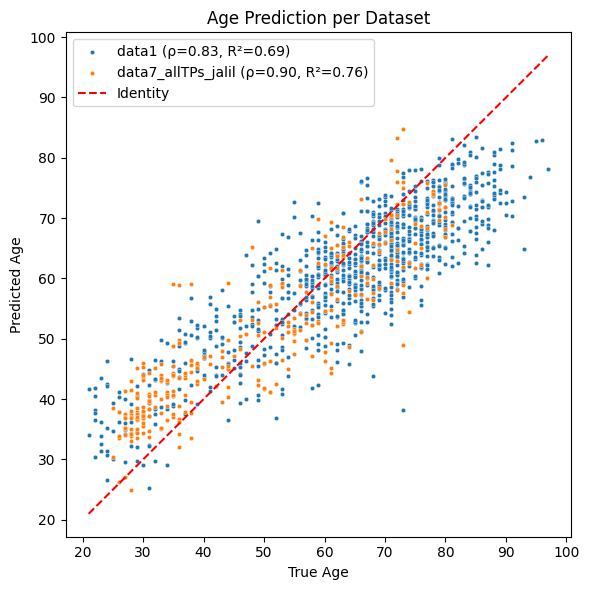

In [22]:
# adata_train = model.predict_age(adata_train)
plot_age_prediction(adata_train)

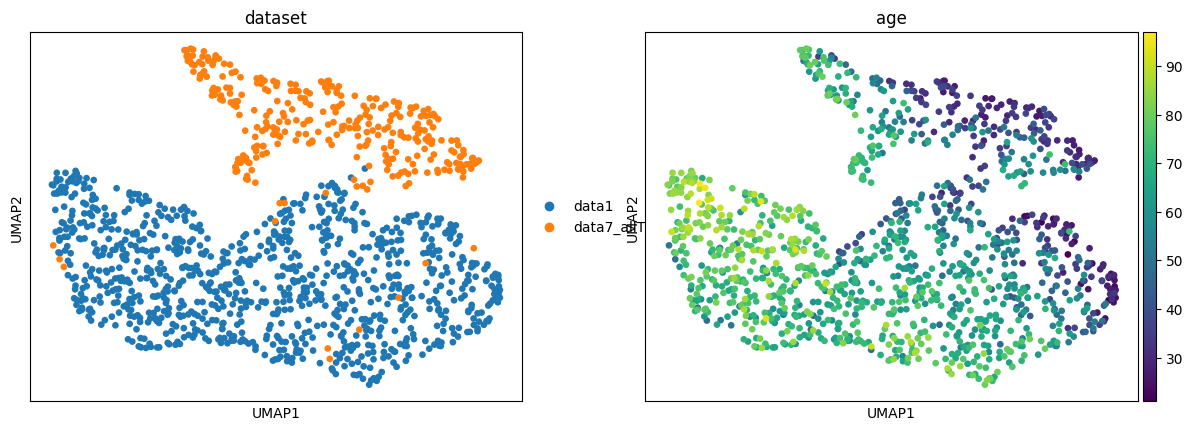

In [ ]:
import scanpy as sc
X_latent = model.get_latent_representation(return_dist=False, give_mean=True)
adata.obsm["X_latent"] = X_latent
# Use latent space for UMAP
sc.pp.neighbors(adata, use_rep="X_latent")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["dataset", "age"])  # adjust based on your obs keys

In [13]:
if False:
    model_dir = os.path.join(save_dir.name, "saved_model")

    model.save(model_dir, save_anndata=True)
    model = SCVI.load(model_dir)